To run this, press "*Runtime*" and press "*Run all*" on a **free** Tesla T4 Google Colab instance!
<div class="align-center">
<a href="https://unsloth.ai/"><img src="https://github.com/unslothai/unsloth/raw/main/images/unsloth%20new%20logo.png" width="115"></a>
<a href="https://discord.gg/unsloth"><img src="https://github.com/unslothai/unsloth/raw/main/images/Discord button.png" width="145"></a>
<a href="https://docs.unsloth.ai/"><img src="https://github.com/unslothai/unsloth/blob/main/images/documentation%20green%20button.png?raw=true" width="125"></a></a> Join Discord if you need help + ⭐ <i>Star us on <a href="https://github.com/unslothai/unsloth">Github</a> </i> ⭐
</div>

To install Unsloth your local device, follow [our guide](https://docs.unsloth.ai/get-started/install-and-update). This notebook is licensed [LGPL-3.0](https://github.com/unslothai/notebooks?tab=LGPL-3.0-1-ov-file#readme).

You will learn how to do [data prep](#Data), how to [train](#Train), how to [run the model](#Inference), & [how to save it](#Save)


### News

Long-Context GRPO for reinforcement learning — train stably at massive sequence lengths. Fine-tune models with up to 7x more context length efficiently. [Read Blog](https://unsloth.ai/docs/new/grpo-long-context)

3× faster training with optimized sequence packing — higher throughput with no quality loss.[Read Blog](https://unsloth.ai/docs/new/3x-faster-training-packing)

500k context-length fine-tuning — push long-context models further with memory-efficient training. [Read Blog](https://unsloth.ai/docs/new/500k-context-length-fine-tuning)

Introducing FP8 precision training for faster RL inference. [Read Blog](https://docs.unsloth.ai/new/fp8-reinforcement-learning).

Unsloth's [Docker image](https://hub.docker.com/r/unsloth/unsloth) is here! Start training with no setup & environment issues. [Read our Guide](https://docs.unsloth.ai/new/how-to-train-llms-with-unsloth-and-docker).

Visit our docs for all our [model uploads](https://docs.unsloth.ai/get-started/all-our-models) and [notebooks](https://docs.unsloth.ai/get-started/unsloth-notebooks).


### Installation

In [1]:
# %%capture
import os, re
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth
else:
    # Do this only in Colab notebooks! Otherwise use pip install unsloth
    import torch; v = re.match(r"[0-9]{1,}\.[0-9]{1,}", str(torch.__version__)).group(0)
    xformers = "xformers==" + ("0.0.33.post1" if v=="2.9" else "0.0.32.post2" if v=="2.8" else "0.0.29.post3")
    !pip install --no-deps bitsandbytes accelerate {xformers} peft trl triton cut_cross_entropy unsloth_zoo
    !pip install sentencepiece protobuf "datasets==4.3.0" "huggingface_hub>=0.34.0" hf_transfer
    !pip install --no-deps unsloth
!pip install transformers==4.57.1
!pip install --no-deps trl==0.22.2

### Unsloth

In [2]:
from unsloth import FastVisionModel # FastLanguageModel for LLMs
import torch

# 4bit pre quantized models we support for 4x faster downloading + no OOMs.
fourbit_models = [
    "unsloth/Llama-3.2-11B-Vision-Instruct-bnb-4bit", # Llama 3.2 vision support
    "unsloth/Llama-3.2-11B-Vision-bnb-4bit",
    "unsloth/Llama-3.2-90B-Vision-Instruct-bnb-4bit", # Can fit in a 80GB card!
    "unsloth/Llama-3.2-90B-Vision-bnb-4bit",

    "unsloth/Pixtral-12B-2409-bnb-4bit",              # Pixtral fits in 16GB!
    "unsloth/Pixtral-12B-Base-2409-bnb-4bit",         # Pixtral base model

    "unsloth/Qwen2-VL-2B-Instruct-bnb-4bit",          # Qwen2 VL support
    "unsloth/Qwen2-VL-7B-Instruct-bnb-4bit",
    "unsloth/Qwen2-VL-72B-Instruct-bnb-4bit",

    "unsloth/llava-v1.6-mistral-7b-hf-bnb-4bit",      # Any Llava variant works!
    "unsloth/llava-1.5-7b-hf-bnb-4bit",
] # More models at https://huggingface.co/unsloth

model, tokenizer = FastVisionModel.from_pretrained(
    "unsloth/Qwen3-VL-8B-Instruct-unsloth-bnb-4bit",
    load_in_4bit = True, # Use 4bit to reduce memory use. False for 16bit LoRA.
    use_gradient_checkpointing = "unsloth", # True or "unsloth" for long context
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


/home/aimachine/Qwen3-VL-Fine-tunning/Qwen-3B-VL-Fine-Tunning/qwen_venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.1.4: Fast Qwen3_Vl patching. Transformers: 4.57.1.
   \\   /|    NVIDIA GeForce RTX 5090. Num GPUs = 1. Max memory: 31.356 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 12.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00,  3.11it/s]


We now add LoRA adapters for parameter efficient finetuning - this allows us to only efficiently train 1% of all parameters.

**[NEW]** We also support finetuning ONLY the vision part of the model, or ONLY the language part. Or you can select both! You can also select to finetune the attention or the MLP layers!

In [3]:
model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers     = True, # False if not finetuning vision layers
    finetune_language_layers   = True, # False if not finetuning language layers
    finetune_attention_modules = True, # False if not finetuning attention layers
    finetune_mlp_modules       = True, # False if not finetuning MLP layers

    r = 16,           # The larger, the higher the accuracy, but might overfit
    lora_alpha = 16,  # Recommended alpha == r at least
    lora_dropout = 0,
    bias = "none",
    random_state = 3407,
    use_rslora = False,  # We support rank stabilized LoRA
    loftq_config = None, # And LoftQ
    # target_modules = "all-linear", # Optional now! Can specify a list if needed
)

<a name="Data"></a>
### Data Prep
We'll be using a sampled dataset of handwritten maths formulas. The goal is to convert these images into a computer readable form - ie in LaTeX form, so we can render it. This can be very useful for complex formulas.

You can access the dataset [here](https://huggingface.co/datasets/unsloth/LaTeX_OCR). The full dataset is [here](https://huggingface.co/datasets/linxy/LaTeX_OCR).

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import os
from PIL import Image
from datasets import Dataset

# Your custom dataset path
DATASET_PATH = "/home/aimachine/Qwen3-VL-Fine-tunning/Qwen-3B-VL-Fine-Tunning/Qwen vl 8b Fine tunning/Floor Plan Walls.v5i.yolov8"

def load_json_labels(label_path):
    """Load JSON format labels as text."""
    if not os.path.exists(label_path):
        return ""
    with open(label_path, 'r') as f:
        return f.read().strip()

def load_custom_dataset(dataset_path, split="train"):
    """Load floor plan dataset with JSON labels."""
    images_dir = os.path.join(dataset_path, split, "images")
    # Point to the new JSON labels directory
    labels_dir = os.path.join(dataset_path, split, "labels_json")

    data = {"image": [], "text": []}

    if not os.path.exists(labels_dir):
        print(f"Warning: Labels directory {labels_dir} not found!")
        return Dataset.from_dict(data)

    image_files = [f for f in os.listdir(images_dir)
                   if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    print(f"Loading {len(image_files)} images from {split}...")

    for img_file in image_files:
        img_path = os.path.join(images_dir, img_file)
        # Label filename is same as image filename but with .txt extension
        label_file = os.path.splitext(img_file)[0] + ".txt"
        label_path = os.path.join(labels_dir, label_file)

        try:
            img = Image.open(img_path).convert("RGB")
            json_labels = load_json_labels(label_path)
            if json_labels:
                data["image"].append(img)
                data["text"].append(json_labels)
        except Exception as e:
            print(f"Error: {img_file}: {e}")

    print(f"Loaded {len(data['image'])} samples")
    return Dataset.from_dict(data)

# Load both Train and Validation datasets
dataset = load_custom_dataset(DATASET_PATH, split="train")
val_dataset = load_custom_dataset(DATASET_PATH, split="valid")

Loading 6639 images from train...
Error: 698_png.rf.c1e6f9664f77b42834abd2a69b0ae424.jpg: cannot identify image file '/home/aimachine/Qwen3-VL-Fine-tunning/Qwen-3B-VL-Fine-Tunning/Qwen vl 8b Fine tunning/Floor Plan Walls.v5i.yolov8/train/images/698_png.rf.c1e6f9664f77b42834abd2a69b0ae424.jpg'
Error: 416_png.rf.4e128a06cf01409a74f0bf65f88f04d5.jpg: cannot identify image file '/home/aimachine/Qwen3-VL-Fine-tunning/Qwen-3B-VL-Fine-Tunning/Qwen vl 8b Fine tunning/Floor Plan Walls.v5i.yolov8/train/images/416_png.rf.4e128a06cf01409a74f0bf65f88f04d5.jpg'
Error: 6020_png.rf.ae356c71684becc84eef91de0ce9e9d5.jpg: cannot identify image file '/home/aimachine/Qwen3-VL-Fine-tunning/Qwen-3B-VL-Fine-Tunning/Qwen vl 8b Fine tunning/Floor Plan Walls.v5i.yolov8/train/images/6020_png.rf.ae356c71684becc84eef91de0ce9e9d5.jpg'
Error: Balleroy-House-Plan-3-_jpg.rf.2b7bb2f21a595aec8f878cb45c46a03d.jpg: cannot identify image file '/home/aimachine/Qwen3-VL-Fine-tunning/Qwen-3B-VL-Fine-Tunning/Qwen vl 8b Fine tun

Let's take an overview look at the dataset. We shall see what the 3rd image is, and what caption it had.

In [5]:
dataset

Dataset({
    features: ['image', 'text'],
    num_rows: 700
})

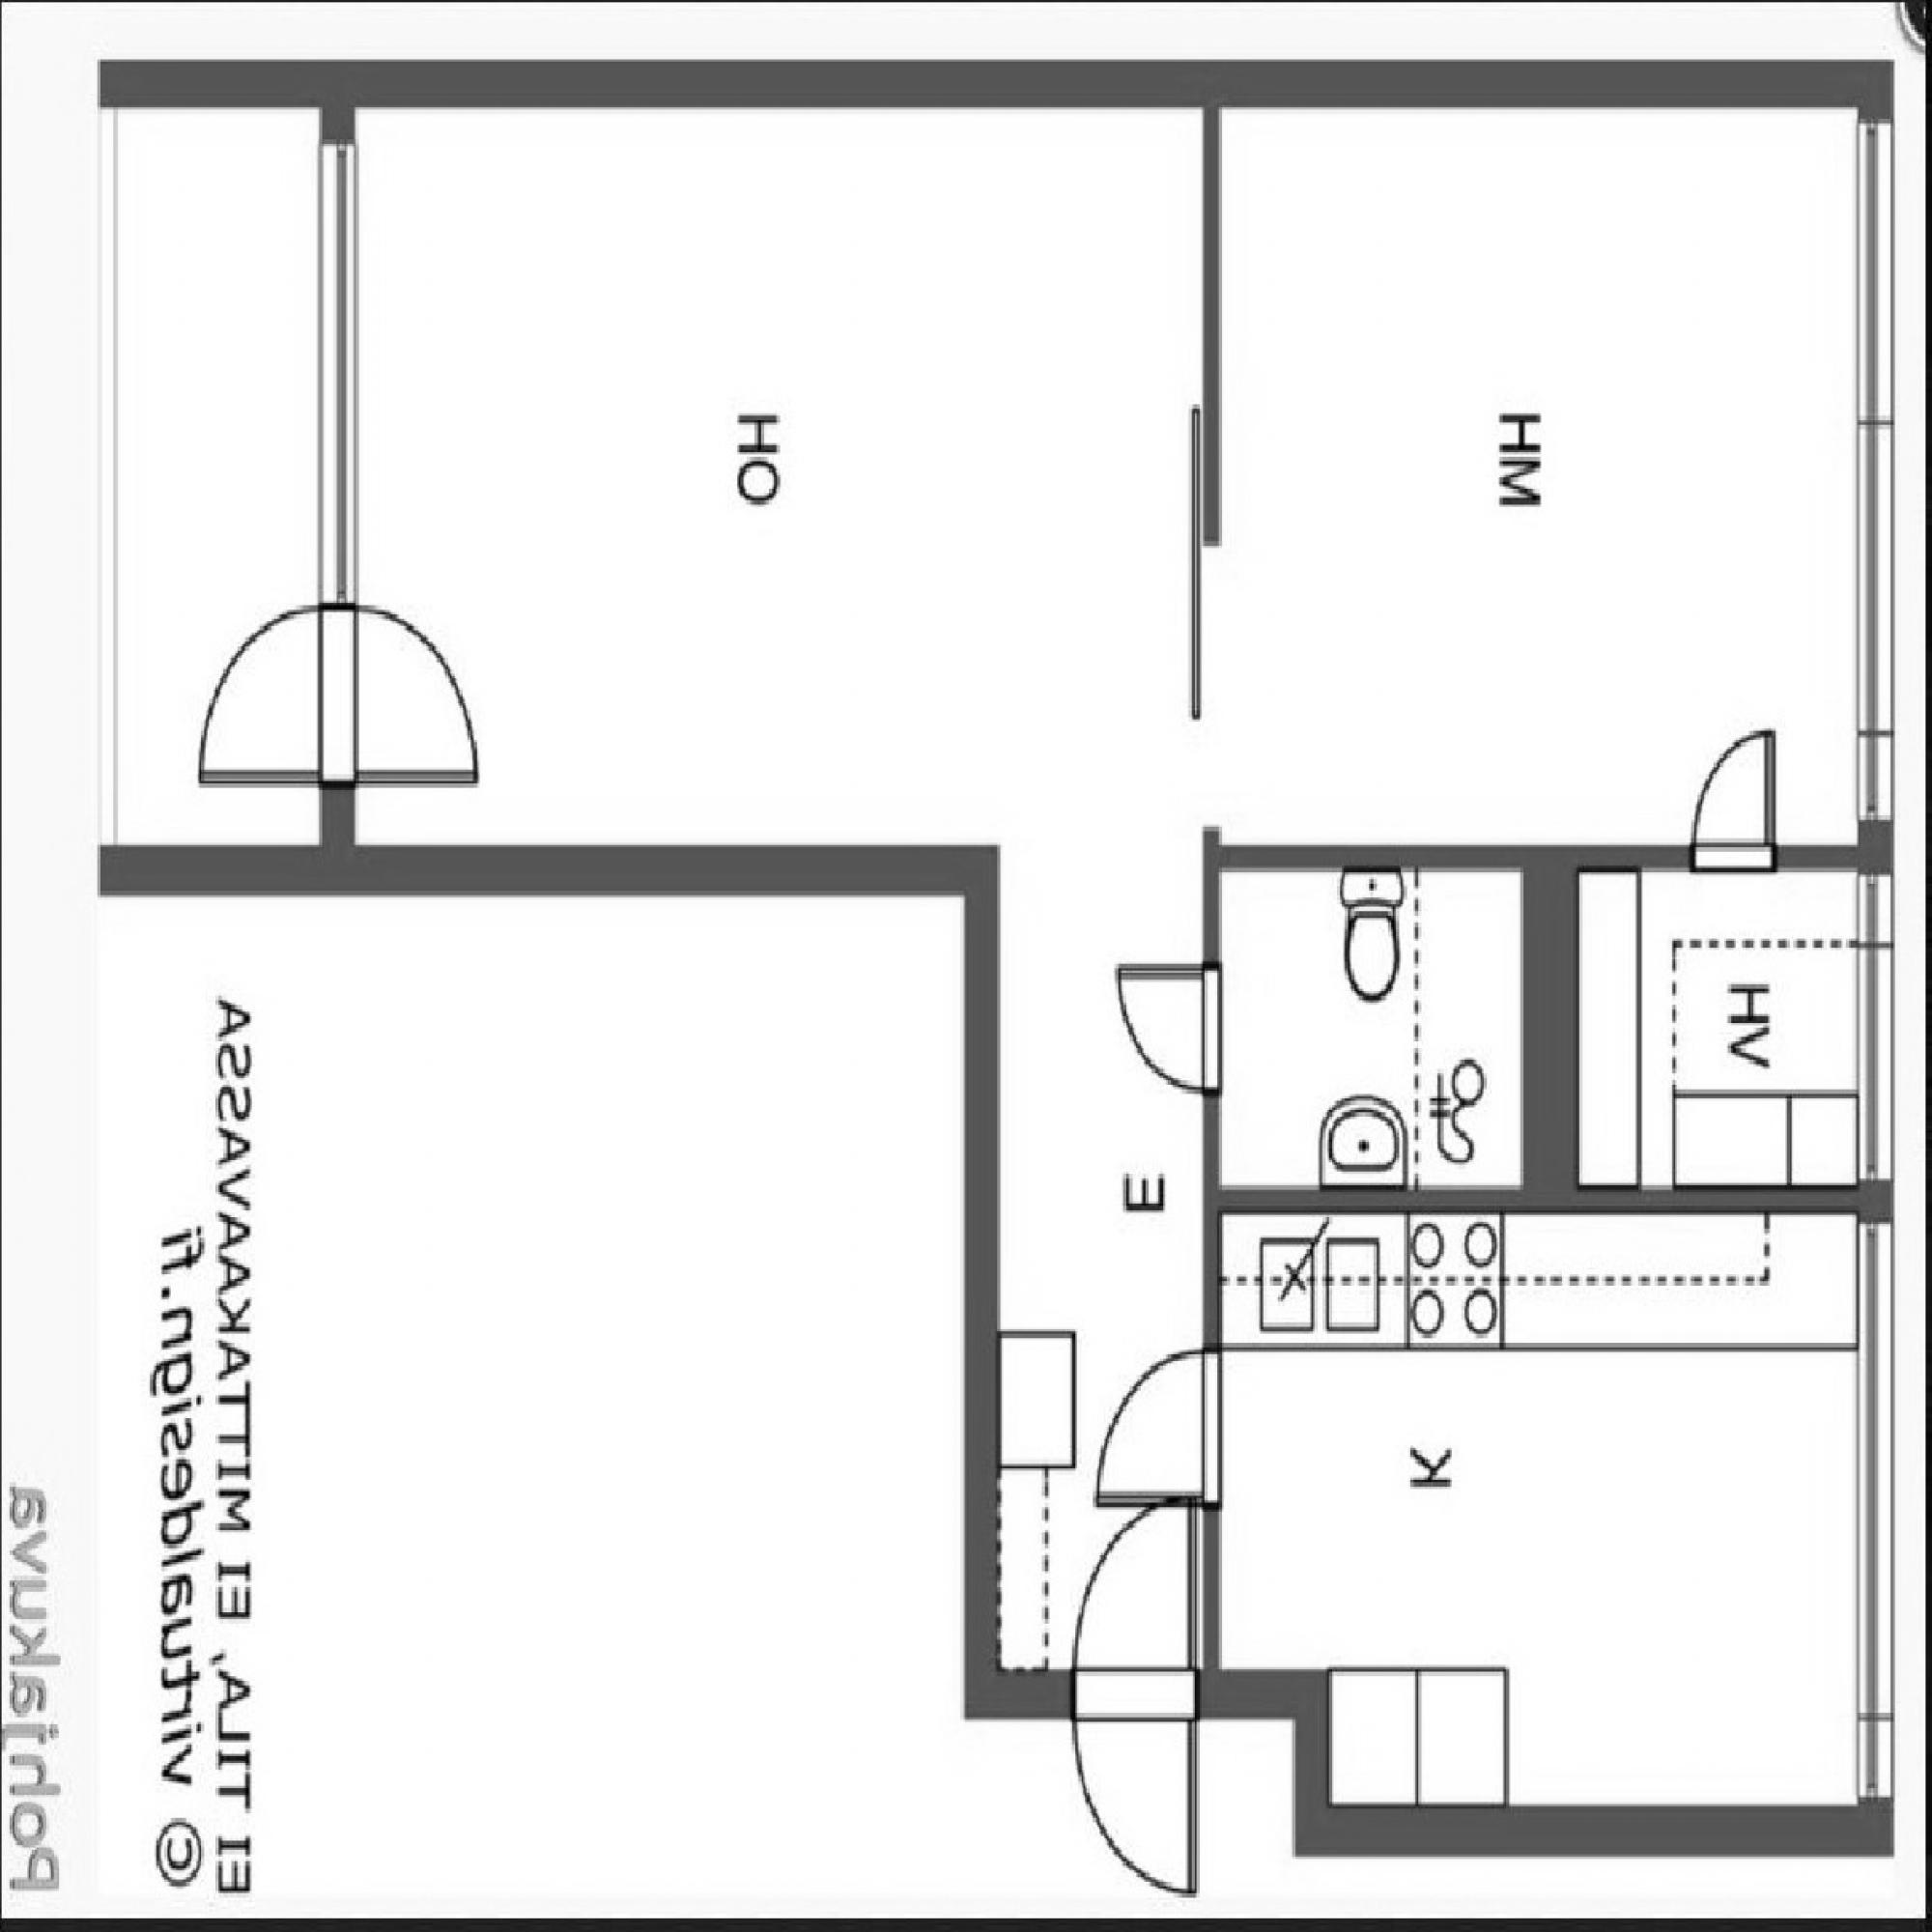

In [6]:
dataset[2]["image"]

In [7]:
dataset[2]["text"]

'{"walls":[{"bbox":[-92,231,424,695]},{"bbox":[258,669,774,1108]},{"bbox":[343,456,1030,1320]},{"bbox":[343,527,1030,1391]},{"bbox":[489,492,1469,1427]},{"bbox":[489,943,1467,973]},{"bbox":[489,39,1469,69]},{"bbox":[91,448,274,478]},{"bbox":[307,444,939,1333]},{"bbox":[307,139,939,418]},{"bbox":[489,318,1467,932]},{"bbox":[489,230,1467,667]},{"bbox":[379,312,1196,937]}]}'

We can also render the LaTeX in the browser directly!

In [8]:
from IPython.display import display, Math, Latex

latex = dataset[2]["text"]
display(Math(latex))

<IPython.core.display.Math object>

To format the dataset, all vision finetuning tasks should be formatted as follows:

```python
[
{ "role": "user",
  "content": [{"type": "text",  "text": Q}, {"type": "image", "image": image} ]
},
{ "role": "assistant",
  "content": [{"type": "text",  "text": A} ]
},
]
```

In [9]:
instruction = "Detect all walls in this floor plan and output the result in JSON format: {'walls': [{'bbox': [x_min, y_min, x_max, y_max]}, ...]}"

def convert_to_conversation(sample):
    conversation = [
        { "role": "user",
          "content" : [
            {"type" : "text",  "text"  : instruction},
            {"type" : "image", "image" : sample["image"]} ]
        },
        { "role" : "assistant",
          "content" : [
            {"type" : "text",  "text"  : sample["text"]} ]
        },
    ]
    return { "messages" : conversation }

Let's convert the dataset into the "correct" format for finetuning:

In [10]:
converted_dataset = [convert_to_conversation(sample) for sample in dataset]
converted_val_dataset = [convert_to_conversation(sample) for sample in val_dataset]

We look at how the conversations are structured for the first example:

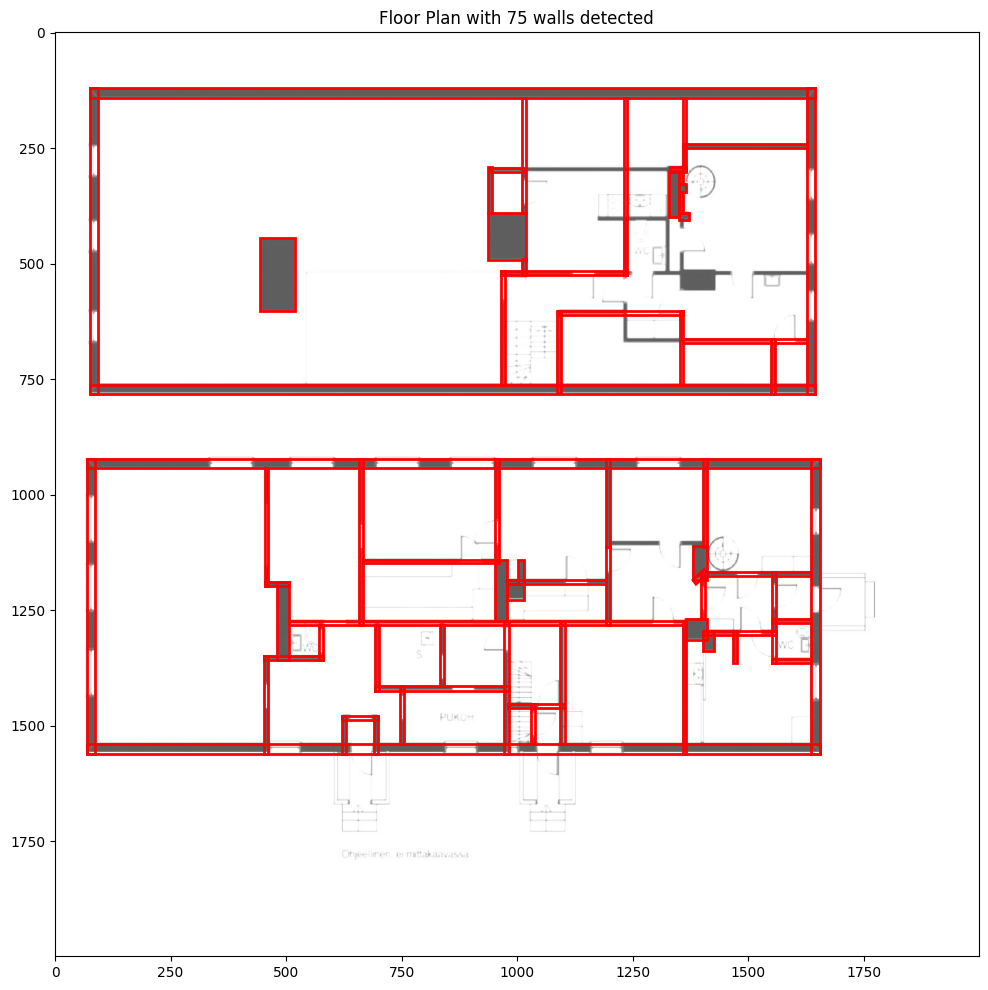

In [16]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

# Get a sample
sample = dataset[0]  # or whatever your dataset variable is
converted = convert_to_conversation(sample)

# Extract image and labels
img = converted['messages'][0]['content'][1]['image']
labels_text = converted['messages'][1]['content'][0]['text']

# Plot
fig, ax = plt.subplots(figsize=(12, 12))
ax.imshow(img)

# Parse and draw each wall polygon
w, h = img.size
for line in labels_text.strip().split('\n'):
    parts = line.split()
    class_id = int(parts[0])
    coords = [float(x) for x in parts[1:]]
    
    # Convert normalized coords to pixel coords
    points = []
    for i in range(0, len(coords), 2):
        x = coords[i] * w
        y = coords[i+1] * h
        points.append((x, y))
    
    # Draw polygon
    poly = patches.Polygon(points, fill=False, edgecolor='red', linewidth=2)
    ax.add_patch(poly)

ax.set_title(f"Floor Plan with {len(labels_text.strip().split(chr(10)))} walls detected")
plt.savefig("verification.png", dpi=150, bbox_inches='tight')
plt.show()

In [11]:
converted_dataset[0]

{'messages': [{'role': 'user',
   'content': [{'type': 'text',
     'text': "Detect all walls in this floor plan and output the result in JSON format: {'walls': [{'bbox': [x_min, y_min, x_max, y_max]}, ...]}"},
    {'type': 'image',
     'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=2000x2000>}]},
  {'role': 'assistant',
   'content': [{'type': 'text',
     'text': '{"walls":[{"bbox":[17,225,51,697]},{"bbox":[409,71,1227,851]},{"bbox":[17,380,51,1160]},{"bbox":[17,71,51,851]},{"bbox":[117,235,344,707]},{"bbox":[113,295,340,894]},{"bbox":[120,255,360,934]},{"bbox":[113,335,339,1014]},{"bbox":[113,284,339,1065]},{"bbox":[556,318,809,954]},{"bbox":[339,246,1018,1026]},{"bbox":[363,317,1047,952]},{"bbox":[350,312,1051,982]},{"bbox":[350,321,1051,973]},{"bbox":[392,292,1168,876]},{"bbox":[387,289,1163,878]},{"bbox":[388,306,1164,989]},{"bbox":[387,336,1163,1019]},{"bbox":[371,323,1104,971]},{"bbox":[353,291,1052,875]},{"bbox":[354,230,1056,692]},{"bbox":[349,289,1048,877]},{

Let's first see before we do any finetuning what the model outputs for the first example!

In [25]:
FastVisionModel.for_inference(model) # Enable for inference!

image = dataset[2]["image"]
instruction = "Detect all walls in this floor plan and output their coordinates in YOLO format. Each line: class_id followed by normalized coordinates"

messages = [
    {"role": "user", "content": [
        {"type": "image"},
        {"type": "text", "text": instruction}
    ]}
]
input_text = tokenizer.apply_chat_template(messages, add_generation_prompt = True)
inputs = tokenizer(
    image,
    input_text,
    add_special_tokens = False,
    return_tensors = "pt",
).to("cuda")

from transformers import TextStreamer
text_streamer = TextStreamer(tokenizer, skip_prompt = True)
_ = model.generate(**inputs, streamer = text_streamer, max_new_tokens = 128,
                   use_cache = True, temperature = 1.5, min_p = 0.1)

0 0.46875 0.039871795 0.976 0.039871795 0.981 0.055365853499999995 0.477 0.0607587165 0.47175 0.036419968 0.46875 0.039871795
0 


<a name="Train"></a>
### Train the model
Now let's train our model. We do 60 steps to speed things up, but you can set `num_train_epochs=1` for a full run, and turn off `max_steps=None`. We also support TRL's `DPOTrainer`!

We use our new `UnslothVisionDataCollator` which will help in our vision finetuning setup.

In [13]:
from unsloth.trainer import UnslothVisionDataCollator
from trl import SFTTrainer, SFTConfig

FastVisionModel.for_training(model) # Enable for training!

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    data_collator = UnslothVisionDataCollator(model, tokenizer), # Must use!
    train_dataset = converted_dataset,
    eval_dataset = converted_val_dataset,  # <--- THIS WAS MISSING

    args = SFTConfig(
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 4,
        warmup_steps = 10,
        # max_steps = 30,
        num_train_epochs = 15, # Set this instead of max_steps for full training runs
        learning_rate = 2e-4,
        logging_steps = 1,
        optim = "adamw_8bit",
        weight_decay = 0.001,
        lr_scheduler_type = "cosine",
        seed = 3407,
        output_dir = "outputs",
        report_to = "none",     # For Weights and Biases
        
        eval_strategy = "steps",
        eval_steps = 10,
        per_device_eval_batch_size = 2,
        # You MUST put the below items for vision finetuning:
        remove_unused_columns = False,
        dataset_text_field = "",
        dataset_kwargs = {"skip_prepare_dataset": True},
        max_length = 4096,

        fp16= False,
        bf16= True,
    ),
)

Unsloth: Model does not have a default image size - using 512


In [14]:
# @title Show current memory stats
gpu_stats = torch.cuda.get_device_properties(0)
start_gpu_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
max_memory = round(gpu_stats.total_memory / 1024 / 1024 / 1024, 3)
print(f"GPU = {gpu_stats.name}. Max memory = {max_memory} GB.")
print(f"{start_gpu_memory} GB of memory reserved.")

GPU = NVIDIA GeForce RTX 5090. Max memory = 31.356 GB.
7.738 GB of memory reserved.


In [15]:
trainer_stats = trainer.train()

The model is already on multiple devices. Skipping the move to device specified in `args`.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 700 | Num Epochs = 15 | Total steps = 1,320
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 51,346,944 of 8,818,470,640 (0.58% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,Validation Loss
10,1.004900,0.956771
20,0.760400,0.802711
30,0.847900,0.751647
40,0.773800,0.726531
50,0.677700,0.711379
60,0.732300,0.699009
70,0.797300,0.689944
80,0.665600,0.680558
90,0.726300,0.676360
100,0.645600,0.672558


Unsloth: Not an error, but Qwen3VLForConditionalGeneration does not accept `num_items_in_batch`.
Using gradient accumulation will be very slightly less accurate.
Read more on gradient accumulation issues here: https://unsloth.ai/blog/gradient


KeyboardInterrupt: 

In [23]:
# @title Show final memory and time stats
used_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
used_memory_for_lora = round(used_memory - start_gpu_memory, 3)
used_percentage = round(used_memory / max_memory * 100, 3)
lora_percentage = round(used_memory_for_lora / max_memory * 100, 3)
print(f"{trainer_stats.metrics['train_runtime']} seconds used for training.")
print(
    f"{round(trainer_stats.metrics['train_runtime']/60, 2)} minutes used for training."
)
print(f"Peak reserved memory = {used_memory} GB.")
print(f"Peak reserved memory for training = {used_memory_for_lora} GB.")
print(f"Peak reserved memory % of max memory = {used_percentage} %.")
print(f"Peak reserved memory for training % of max memory = {lora_percentage} %.")

884.6177 seconds used for training.
14.74 minutes used for training.
Peak reserved memory = 10.467 GB.
Peak reserved memory for training = 1.594 GB.
Peak reserved memory % of max memory = 33.381 %.
Peak reserved memory for training % of max memory = 5.084 %.


<a name="Inference"></a>
### Inference
Let's run the model! You can change the instruction and input - leave the output blank!

We use `min_p = 0.1` and `temperature = 1.5`. Read this [Tweet](https://x.com/menhguin/status/1826132708508213629) for more information on why.

In [26]:
FastVisionModel.for_inference(model) # Enable for inference!

image = dataset[2]["image"]
instruction = "Detect all walls in this floor plan and output their coordinates in YOLO format. Each line: class_id followed by normalized coordinates."

messages = [
    {"role": "user", "content": [
        {"type": "image"},
        {"type": "text", "text": instruction}
    ]}
]
input_text = tokenizer.apply_chat_template(messages, add_generation_prompt = True)
inputs = tokenizer(
    image,
    input_text,
    add_special_tokens = False,
    return_tensors = "pt",
).to("cuda")

from transformers import TextStreamer
text_streamer = TextStreamer(tokenizer, skip_prompt = True)
_ = model.generate(**inputs, streamer = text_streamer, max_new_tokens = 128,
                   use_cache = True, temperature = 1.5, min_p = 0.1)

0 0.055500000499999996 0.39874999950000004 0.055500000499999996 0.38625 0.97625 0.38625 0.97625 0.39874999950000004 0.0555000004


PREDICTION:
0 0.4445 0.384 0.796 0.02025
0 0.819 0.1995 0.023 0.389
0 0.681 0.115 0.293 0.02025
0 0.543 0.20025 0.023 0.389
0 0.405 0.2855 0.293 0.02025
0 0.267 0.1995 0.023 0.389
0 0.129 0.115 0.293 0.02025
0 0.091 0.071 0.023 0.105
0 0.091 0.1995 0.023 0.105
0 0.091 0.328 0.023 0.105
0 0.091 0.4565 0.023 0.105
0 0.091 0.77975 0.023 0.105
0 0.091 0.6515 0.023 0.105
0 0.091 0.52325 0.023 0.105
0 0.091 0.4045 0.023 0.105
0 0.819 0.466 0.023 0.105
0 0.819 0.77975 0.023 0.105
0 0.819 0.6515 0.023 0.105
0 0.819 0.52325 0.023 0.105
0 0.819 0.4045 0.023 0.105
0 0.819 0.384 0.023 0.02025
0 0.819 0.466 0.023 0.105
0 0.819 0.77975 0.023 0.105
0 0.819 0.6515 0.023 0.105
0 0.819 0.52325 0.023 0.105
0 0.819 0.4045 0.023 0.105
0 0.819 0.384 0.023 0.02025
0 0.819 0.466 0.023 0.105
0 0.819 0.77975 0.023 0.105
0 0.819 0.6515 0.023 0.105
0 0.819 0.52325 0.023 0.105
0 0.819 0.4045 0.023 0.105
0 0.819 0.384 0.023 0.02025
0 0.819 0.466 0.023 0.105
0 0.819 0.77975 0.023 0.105
0 0.819 0.6515 0.023 0.105
0 0

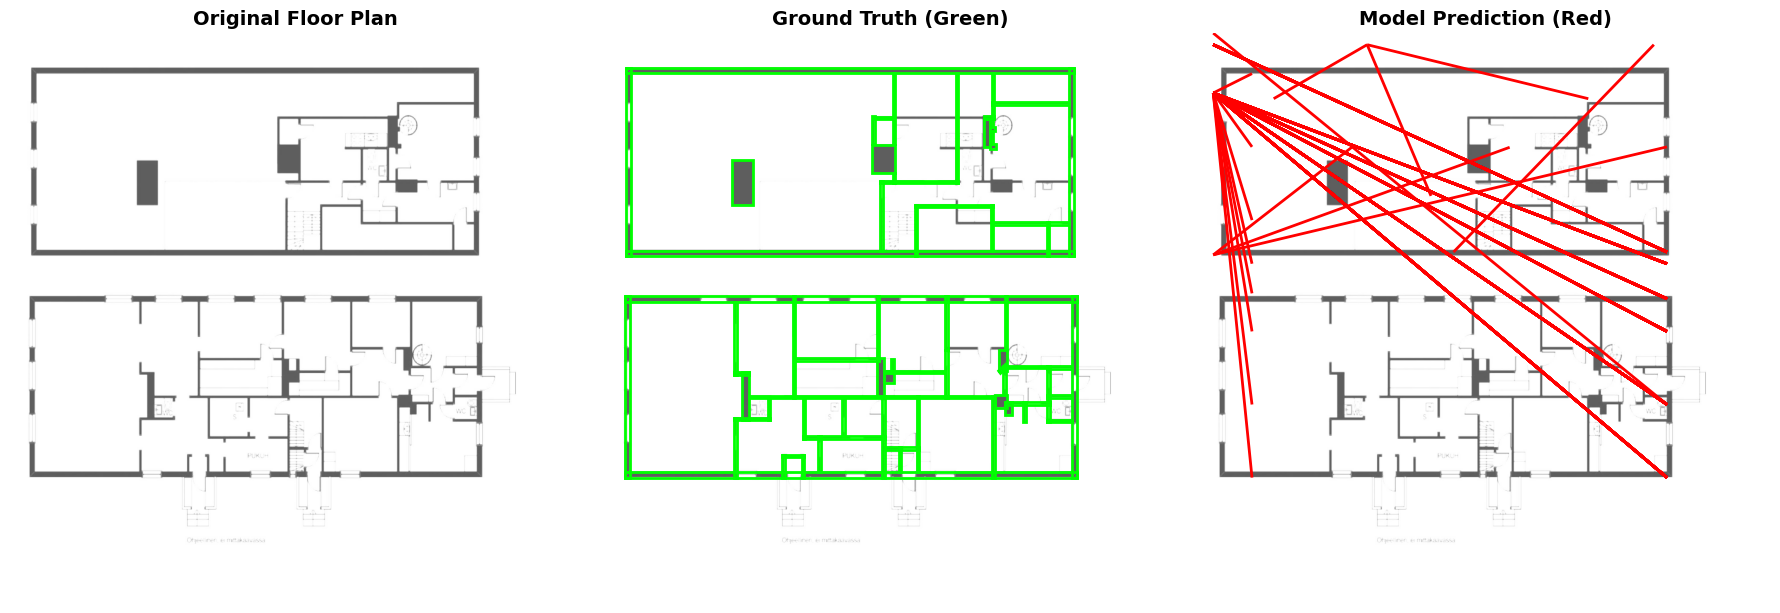

Saved to comparison.png


In [32]:
# ============ CORRECT INFERENCE FOR QWEN3-VL ============

from PIL import Image

# 1. Switch to inference mode
FastVisionModel.for_inference(model)

# 2. Get a test sample
sample = dataset[0]
test_image = sample["image"]
gt_text = sample["text"]

# 3. Create the conversation format (same as training)
messages = [
    {"role": "user", "content": [
        {"type": "image", "image": test_image},
        {"type": "text", "text": instruction},
    ]}
]

# 4. Apply chat template with tokenize=False first
text_prompt = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True,
)

# 5. Now tokenize with the processor (handles both text + image)
from transformers import Qwen2VLProcessor

# Get the processor from the model
processor = Qwen2VLProcessor.from_pretrained(
    "unsloth/Qwen3-VL-8B-Instruct-unsloth-bnb-4bit"
)

inputs = processor(
    text=[text_prompt],
    images=[test_image],
    return_tensors="pt",
    padding=True,
).to("cuda")

# 6. Generate
outputs = model.generate(
    **inputs,
    max_new_tokens=4096,
    temperature=0.1,
    do_sample=True,
)

# 7. Decode - skip the input tokens
generated_ids = outputs[:, inputs.input_ids.shape[1]:]
pred_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

print("=" * 50)
print("PREDICTION:")
print(pred_text[:1000])
print("=" * 50)

# 8. Visualize
visualize_comparison(test_image, gt_text, pred_text, "comparison.png")

<a name="Save"></a>
### Saving, loading finetuned models
To save the final model as LoRA adapters, either use Huggingface's `push_to_hub` for an online save or `save_pretrained` for a local save.

**[NOTE]** This ONLY saves the LoRA adapters, and not the full model. To save to 16bit or GGUF, scroll down!

In [33]:
model.save_pretrained("lora_model")  # Local saving
tokenizer.save_pretrained("lora_model")
# model.push_to_hub("your_name/lora_model", token = "...") # Online saving
# tokenizer.push_to_hub("your_name/lora_model", token = "...") # Online saving

[]

Now if you want to load the LoRA adapters we just saved for inference, set `False` to `True`:

In [37]:
if False:
    from unsloth import FastVisionModel
    model, tokenizer = FastVisionModel.from_pretrained(
        model_name = "lora_model", # YOUR MODEL YOU USED FOR TRAINING
        load_in_4bit = True, # Set to False for 16bit LoRA
    )
    FastVisionModel.for_inference(model) # Enable for inference!

image = dataset[0]["image"]
instruction = "Write me walls dimentions in proper yolo format"

messages = [
    {"role": "user", "content": [
        {"type": "image"},
        {"type": "text", "text": instruction}
    ]}
]
input_text = tokenizer.apply_chat_template(messages, add_generation_prompt = True)
inputs = tokenizer(
    image,
    input_text,
    add_special_tokens = False,
    return_tensors = "pt",
).to("cuda")

from transformers import TextStreamer
text_streamer = TextStreamer(tokenizer, skip_prompt = True)
_ = model.generate(**inputs, streamer = text_streamer, max_new_tokens = 128,
                   use_cache = True, temperature = 1.5, min_p = 0.1)

0 0.4765 0.38175 0.64275 0.0195
0 0.121 0.19125 0.0225 0.3915
0 0.121 0.496 0.0225 0.34675
0 0.18475 0.44775 0.273 0.019
0 0.248


### Saving to float16 for VLLM

We also support saving to `float16` directly. Select `merged_16bit` for float16. Use `push_to_hub_merged` to upload to your Hugging Face account! You can go to https://huggingface.co/settings/tokens for your personal tokens.

In [ ]:
# Select ONLY 1 to save! (Both not needed!)

# Save locally to 16bit
if False: model.save_pretrained_merged("unsloth_finetune", tokenizer,)

# To export and save to your Hugging Face account
if False: model.push_to_hub_merged("YOUR_USERNAME/unsloth_finetune", tokenizer, token = "PUT_HERE")

### GGUF / llama.cpp Conversion
To save to `GGUF` / `llama.cpp`, we support it natively now! We clone `llama.cpp` and we default save it to `q8_0`. We allow all methods like `q4_k_m`. Use `save_pretrained_gguf` for local saving and `push_to_hub_gguf` for uploading to HF.

Some supported quant methods (full list on our [Wiki page](https://github.com/unslothai/unsloth/wiki#gguf-quantization-options)):
* `q8_0` - Fast conversion. High resource use, but generally acceptable.
* `q4_k_m` - Recommended. Uses Q6_K for half of the attention.wv and feed_forward.w2 tensors, else Q4_K.
* `q5_k_m` - Recommended. Uses Q6_K for half of the attention.wv and feed_forward.w2 tensors, else Q5_K.

[**NEW**] To finetune and auto export to Ollama, try our [Ollama notebook](https://colab.research.google.com/github/unslothai/notebooks/blob/main/nb/Llama3_(8B)-Ollama.ipynb)

In [ ]:
# Save to 8bit Q8_0
if False: model.save_pretrained_gguf("unsloth_finetune", tokenizer,)
# Remember to go to https://huggingface.co/settings/tokens for a token!
# And change hf to your username!
if False: model.push_to_hub_gguf("hf/unsloth_finetune", tokenizer, token = "")

# Save to 16bit GGUF
if False: model.save_pretrained_gguf("unsloth_finetune", tokenizer, quantization_method = "f16")
if False: model.push_to_hub_gguf("hf/unsloth_finetune", tokenizer, quantization_method = "f16", token = "")

# Save to q4_k_m GGUF
if False: model.save_pretrained_gguf("unsloth_finetune", tokenizer, quantization_method = "q4_k_m")
if False: model.push_to_hub_gguf("hf/unsloth_finetune", tokenizer, quantization_method = "q4_k_m", token = "")

# Save to multiple GGUF options - much faster if you want multiple!
if False:
    model.push_to_hub_gguf(
        "hf/unsloth_finetune", # Change hf to your username!
        tokenizer,
        quantization_method = ["q4_k_m", "q8_0", "q5_k_m",],
        token = "",
    )

Now, use the `model-unsloth.gguf` file or `model-unsloth-Q4_K_M.gguf` file in llama.cpp.

And we're done! If you have any questions on Unsloth, we have a [Discord](https://discord.gg/unsloth) channel! If you find any bugs or want to keep updated with the latest LLM stuff, or need help, join projects etc, feel free to join our Discord!

Some other links:
1. Train your own reasoning model - Llama GRPO notebook [Free Colab](https://colab.research.google.com/github/unslothai/notebooks/blob/main/nb/Llama3.1_(8B)-GRPO.ipynb)
2. Saving finetunes to Ollama. [Free notebook](https://colab.research.google.com/github/unslothai/notebooks/blob/main/nb/Llama3_(8B)-Ollama.ipynb)
3. Llama 3.2 Vision finetuning - Radiography use case. [Free Colab](https://colab.research.google.com/github/unslothai/notebooks/blob/main/nb/Llama3.2_(11B)-Vision.ipynb)
6. See notebooks for DPO, ORPO, Continued pretraining, conversational finetuning and more on our [documentation](https://docs.unsloth.ai/get-started/unsloth-notebooks)!

<div class="align-center">
  <a href="https://unsloth.ai"><img src="https://github.com/unslothai/unsloth/raw/main/images/unsloth%20new%20logo.png" width="115"></a>
  <a href="https://discord.gg/unsloth"><img src="https://github.com/unslothai/unsloth/raw/main/images/Discord.png" width="145"></a>
  <a href="https://docs.unsloth.ai/"><img src="https://github.com/unslothai/unsloth/blob/main/images/documentation%20green%20button.png?raw=true" width="125"></a>

  Join Discord if you need help + ⭐️ <i>Star us on <a href="https://github.com/unslothai/unsloth">Github</a> </i> ⭐️

  This notebook and all Unsloth notebooks are licensed [LGPL-3.0](https://github.com/unslothai/notebooks?tab=LGPL-3.0-1-ov-file#readme).
</div>
